# Módulo: Análisis de Impacto de Amenidades Extras (Garaje y Piscina)

En este cuaderno exploraremos visualmente cuánto influye tener una **Plaza de Garaje** o una **Piscina Comunitaria** en el precio de venta de una vivienda en Madrid. 

El algoritmo matemático que hemos entrenado (`HistGB`) ha aprendido estas relaciones, y aquí las representaremos mediante gráficas.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Cargamos los datos limpios
df = pd.read_csv('../data_pipeline/data/processed/propiedades_limpias.csv')

print(f"Total de viviendas analizadas: {len(df)}")

Total de viviendas analizadas: 5031


## 1. Impacto de la Plaza de Garaje en el Precio Medio

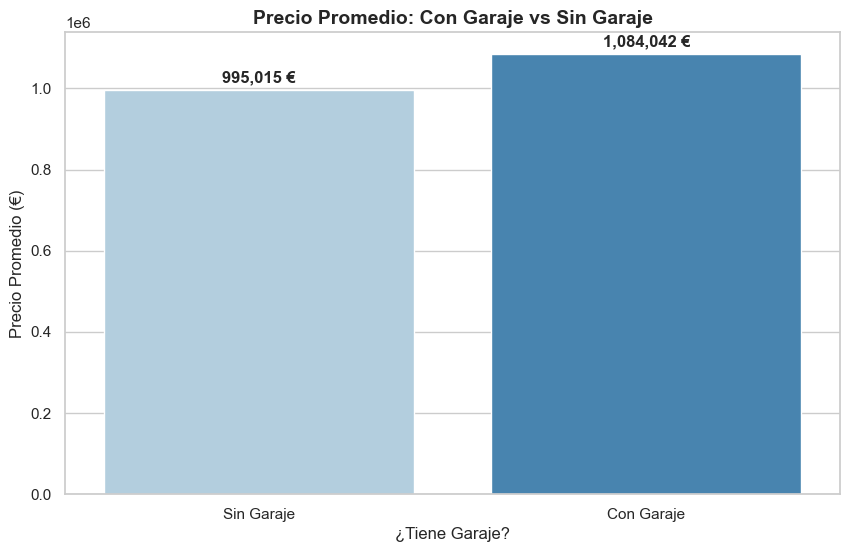

In [2]:
plt.figure(figsize=(10, 6))
ax = from numpy import median
ax = sns.barplot(estimator=median, x='tiene_garaje', y='precio_limpio', data=df, palette='Blues', errorbar=None)

plt.title('Precio Promedio: Con Garaje vs Sin Garaje', fontsize=14, fontweight='bold')
plt.xlabel('¿Tiene Garaje?', fontsize=12)
plt.ylabel('Precio Promedio (€)', fontsize=12)
plt.xticks([0, 1], ['Sin Garaje', 'Con Garaje'], fontsize=11)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} €", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

plt.show()

## 2. Impacto de la Piscina en el Precio por Metro Cuadrado

La piscina comunitaria no solo afecta al precio total, sino que suele ser un indicador de urbanizaciones nuevas, lo que eleva significativamente el precio por metro cuadrado ($€/m^2$).

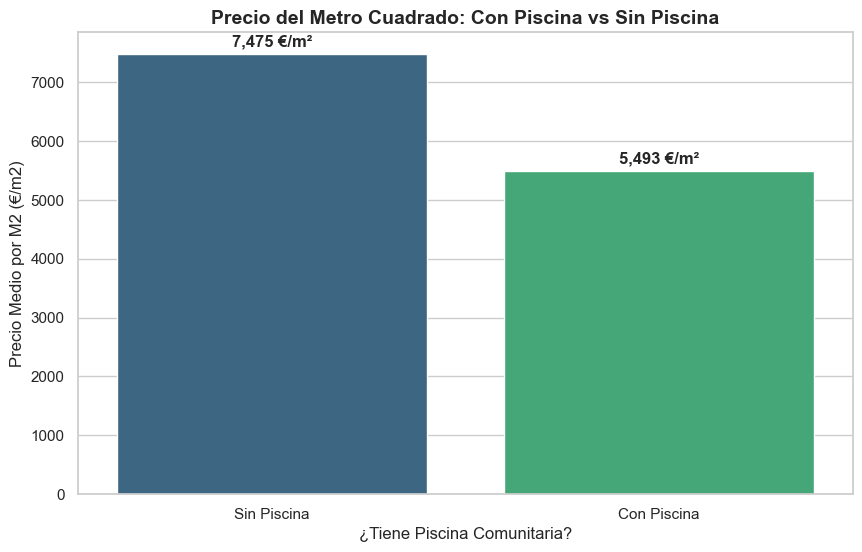

In [5]:
plt.figure(figsize=(10, 6))
ax = from numpy import median
ax = sns.barplot(estimator=median, x='tiene_piscina', y='precio_m2', data=df, palette='viridis', errorbar=None)

plt.title('Precio del Metro Cuadrado: Con Piscina vs Sin Piscina', fontsize=14, fontweight='bold')
plt.xlabel('¿Tiene Piscina Comunitaria?', fontsize=12)
plt.ylabel('Precio Medio por M2 (€/m2)', fontsize=12)
plt.xticks([0, 1], ['Sin Piscina', 'Con Piscina'], fontsize=11)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} €/m²", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

plt.show()

## 3. Distribución de Precios (Boxplot) segmentada por Garaje
Visualizamos cómo se comporta la dispersión de precios dependiendo de si la vivienda incluye o no plaza de aparcamiento.

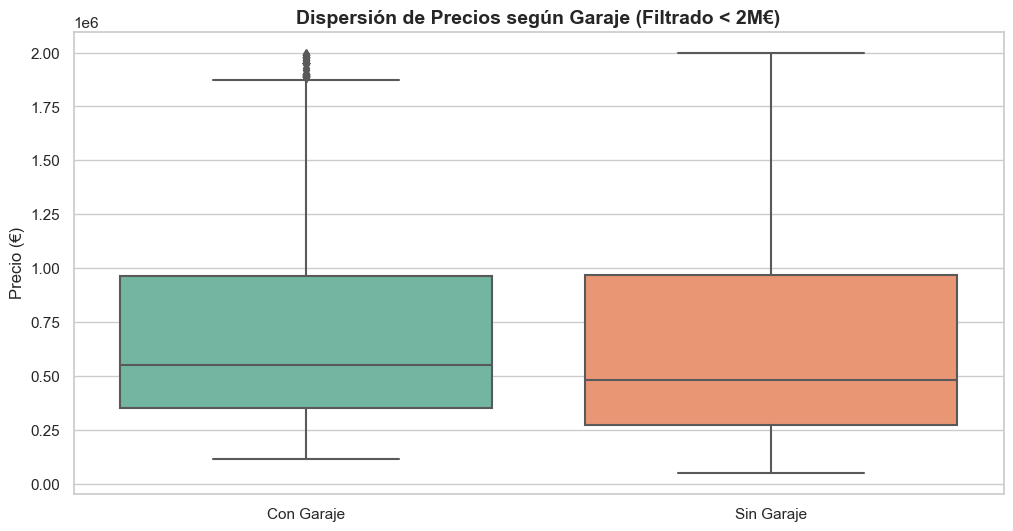

In [4]:
plt.figure(figsize=(12, 6))
# Filtramos para ver mejor la caja principal y quitamos super outliers para la gráfica
df_filtered = df[df['precio_limpio'] < 2000000].copy()

df_filtered['Garaje_Label'] = df_filtered['tiene_garaje'].map({0: 'Sin Garaje', 1: 'Con Garaje'})
sns.boxplot(x='Garaje_Label', y='precio_limpio', data=df_filtered, palette='Set2')

plt.title('Dispersión de Precios según Garaje (Filtrado < 2M€)', fontsize=14, fontweight='bold')
plt.xlabel('', fontsize=12)
plt.ylabel('Precio (€)', fontsize=12)
plt.show()